In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

In [3]:
print("Available Seaborn Datasets:")
print(sns.get_dataset_names())

Available Seaborn Datasets:
['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [4]:
flights = sns.load_dataset('flights')

print("Shape:", flights.shape)
print("\nFirst 5 rows:")
flights.head()

Shape: (144, 3)

First 5 rows:


,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [5]:
print("Summary Statistics:")
flights.describe()

Summary Statistics:


,year,passengers
count,144.000000,144.000000
mean,1954.500000,280.298611
std,3.464102,119.966317
min,1949.000000,104.000000
25%,1951.750000,180.000000
50%,1954.500000,265.500000
75%,1957.250000,360.500000
max,1960.000000,622.000000


In [6]:
flights['date'] = pd.to_datetime(flights['year'].astype(str) + '-' + flights['month'].astype(str))
flights = flights.sort_values('date').reset_index(drop=True)

print("\nData Types:")
print(flights.dtypes)


Data Types:
year                   int64
month               category
passengers             int64
date          datetime64[ns]
dtype: object


/tmp/ipykernel_607/1122911849.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  flights['date'] = pd.to_datetime(flights['year'].astype(str) + '-' + flights['month'].astype(str))


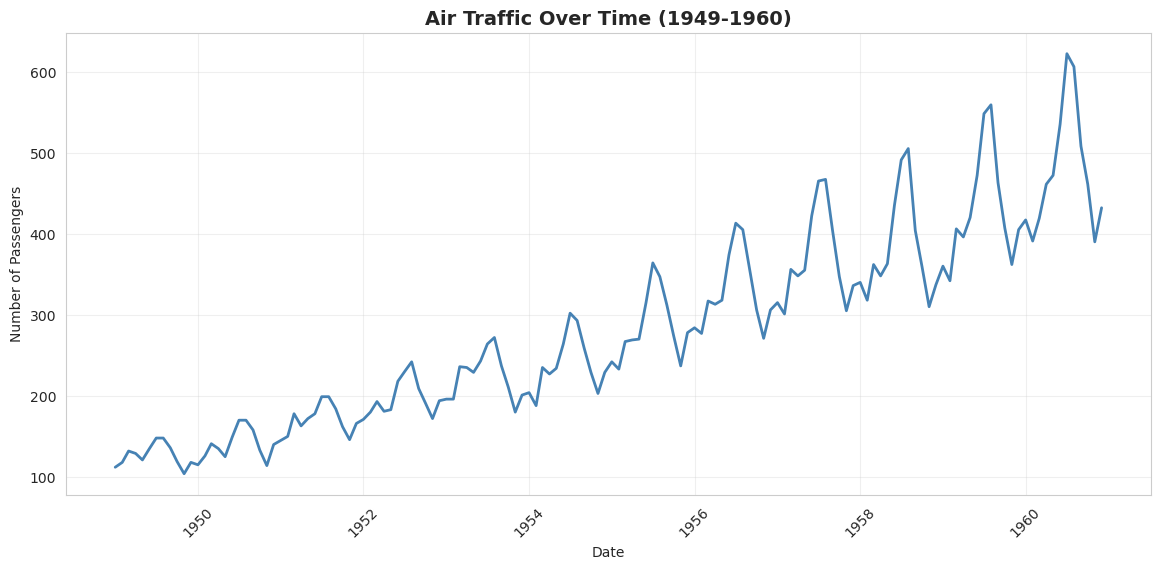

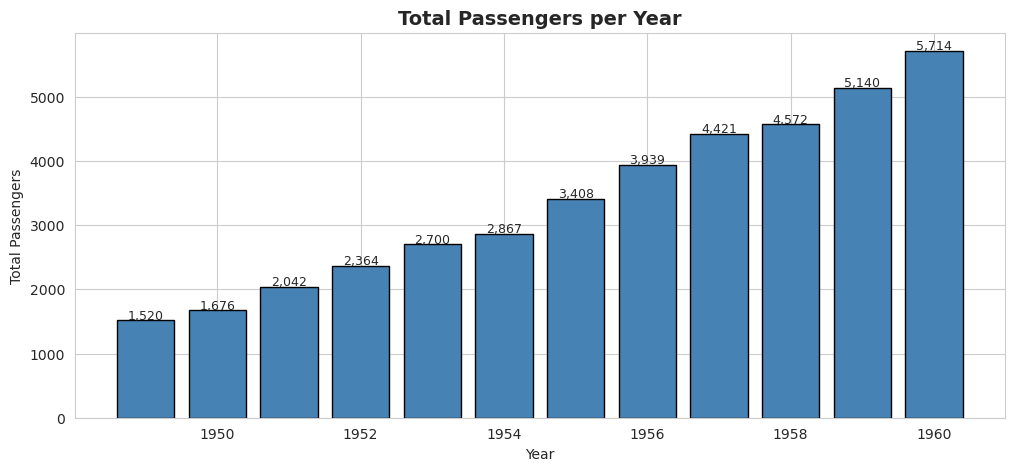

Yearly Passenger Totals:
year
1949    1520
1950    1676
1951    2042
1952    2364
1953    2700
1954    2867
1955    3408
1956    3939
1957    4421
1958    4572
1959    5140
1960    5714
Name: passengers, dtype: int64


In [7]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=flights, x='date', y='passengers', color='steelblue', linewidth=2)
plt.title('Air Traffic Over Time (1949-1960)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

yearly = flights.groupby('year')['passengers'].sum()
plt.figure(figsize=(12, 5))
bars = plt.bar(yearly.index, yearly.values, color='steelblue', edgecolor='black')
plt.title('Total Passengers per Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Passengers')

for bar, value in zip(bars, yearly.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{value:,}', ha='center', fontsize=9)

plt.show()

print("Yearly Passenger Totals:")
print(yearly)

/tmp/ipykernel_607/1674643851.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = flights.groupby('month')['passengers'].mean().reindex(
/tmp/ipykernel_607/1674643851.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette='viridis', ax=axes[0])
/tmp/ipykernel_607/1674643851.py:12: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  flights_pivot = flights.pivot_table(index='year', columns='month',


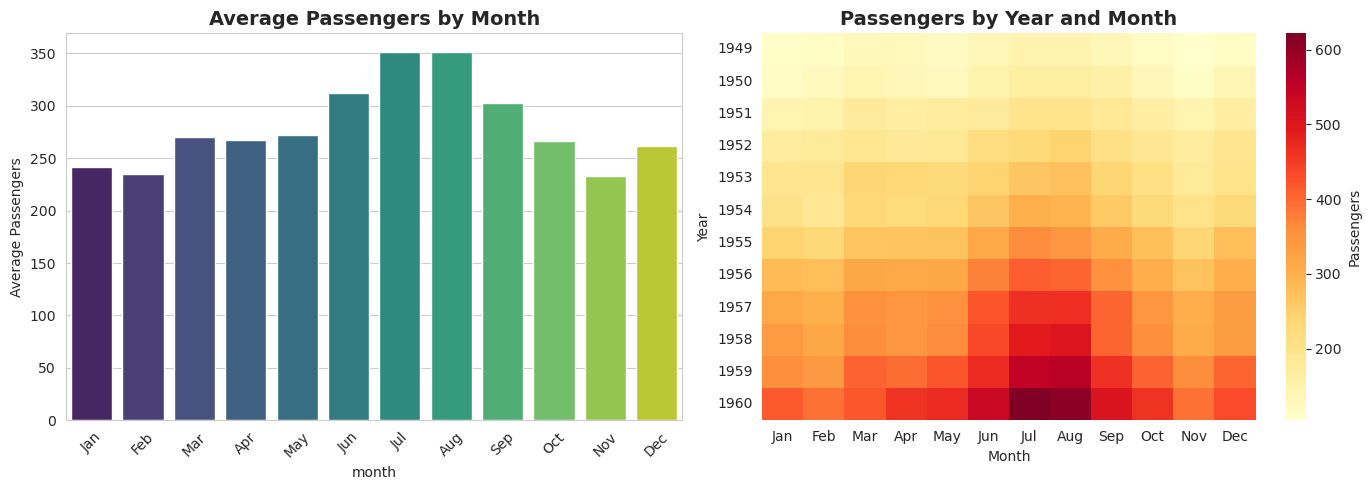

Average Passengers by Month:
month
Jan    242
Feb    235
Mar    270
Apr    267
May    272
Jun    312
Jul    351
Aug    351
Sep    302
Oct    267
Nov    233
Dec    262
Name: passengers, dtype: int64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

monthly_avg = flights.groupby('month')['passengers'].mean().reindex(
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette='viridis', ax=axes[0])
axes[0].set_title('Average Passengers by Month', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Average Passengers')
axes[0].tick_params(axis='x', rotation=45)

flights_pivot = flights.pivot_table(index='year', columns='month',
                                     values='passengers', aggfunc='sum')
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
flights_pivot = flights_pivot[month_order]

sns.heatmap(flights_pivot, cmap='YlOrRd', annot=False, fmt='d',
            ax=axes[1], cbar_kws={'label': 'Passengers'})
axes[1].set_title('Passengers by Year and Month', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Year')

plt.tight_layout()
plt.show()

print("Average Passengers by Month:")
print(monthly_avg.round(0).astype(int))

Year with highest passengers: 1960 (5,714 passengers)


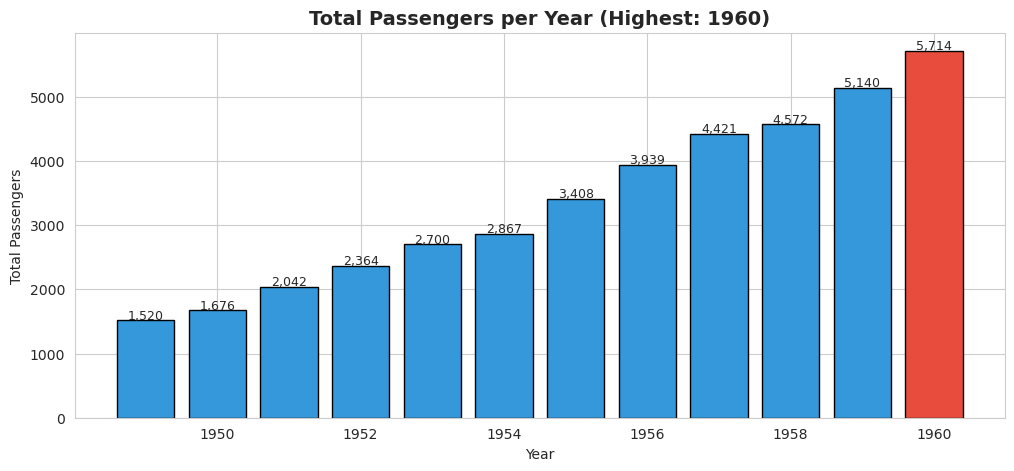

In [10]:
max_year = yearly.idxmax()
max_value = yearly.max()

print(f"Year with highest passengers: {max_year} ({max_value:,} passengers)")

plt.figure(figsize=(12, 5))
colors = ['#e74c3c' if y == max_year else '#3498db' for y in yearly.index]
bars = plt.bar(yearly.index, yearly.values, color=colors, edgecolor='black')
plt.title(f'Total Passengers per Year (Highest: {max_year})', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Passengers')

for bar, value in zip(bars, yearly.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{value:,}', ha='center', fontsize=9)

plt.show()

/tmp/ipykernel_607/1747643462.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_stats = flights.groupby('month')['passengers'].agg(['mean', 'std', 'min', 'max'])
/tmp/ipykernel_607/1747643462.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=flights, x='month', y='passengers', palette='Set3',


Monthly Statistics:
        mean    std  min  max
month                        
Jan    241.8  101.0  112  417
Feb    235.0   89.6  118  391
Mar    270.2  100.6  132  419
Apr    267.1  107.4  129  461
May    271.8  114.7  121  472
Jun    311.7  134.2  135  535
Jul    351.3  156.8  148  622
Aug    351.1  155.8  148  606
Sep    302.4  124.0  136  508
Oct    266.6  110.7  119  461
Nov    232.8   95.2  104  390
Dec    261.8  103.1  118  432


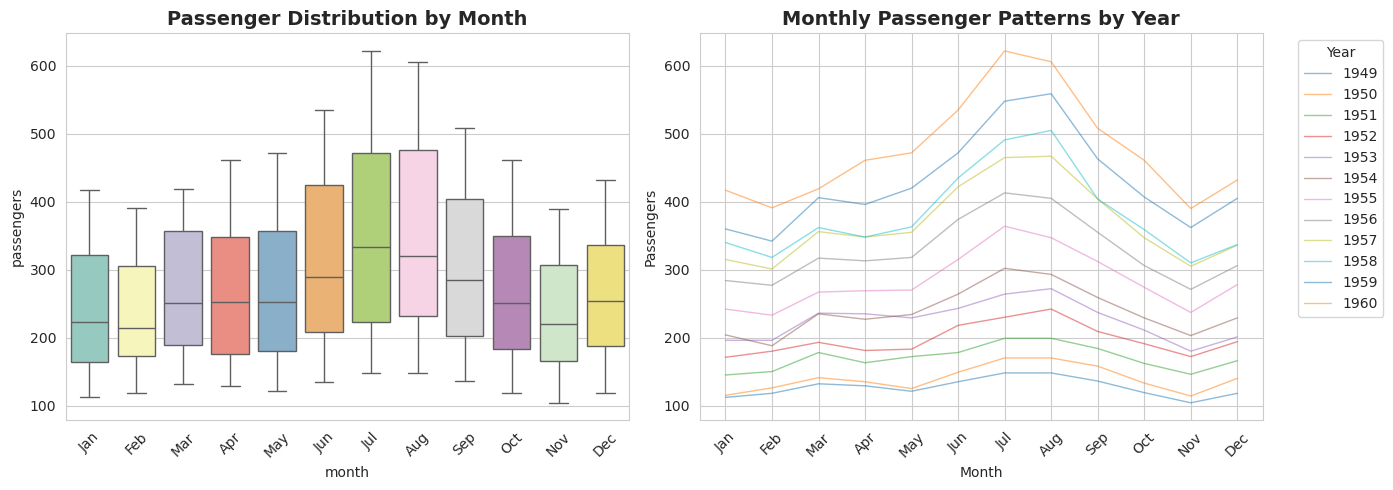

In [11]:
monthly_stats = flights.groupby('month')['passengers'].agg(['mean', 'std', 'min', 'max'])
monthly_stats = monthly_stats.reindex(month_order)

print("Monthly Statistics:")
print(monthly_stats.round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=flights, x='month', y='passengers', palette='Set3',
            order=month_order, ax=axes[0])
axes[0].set_title('Passenger Distribution by Month', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

for year in flights['year'].unique():
    year_data = flights[flights['year'] == year]
    axes[1].plot(year_data['month'], year_data['passengers'],
                 alpha=0.5, linewidth=1)

axes[1].set_title('Monthly Passenger Patterns by Year', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Passengers')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(flights['year'].unique(), title='Year', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

/tmp/ipykernel_607/3199601166.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = flights.pivot_table(index='year', columns='month',


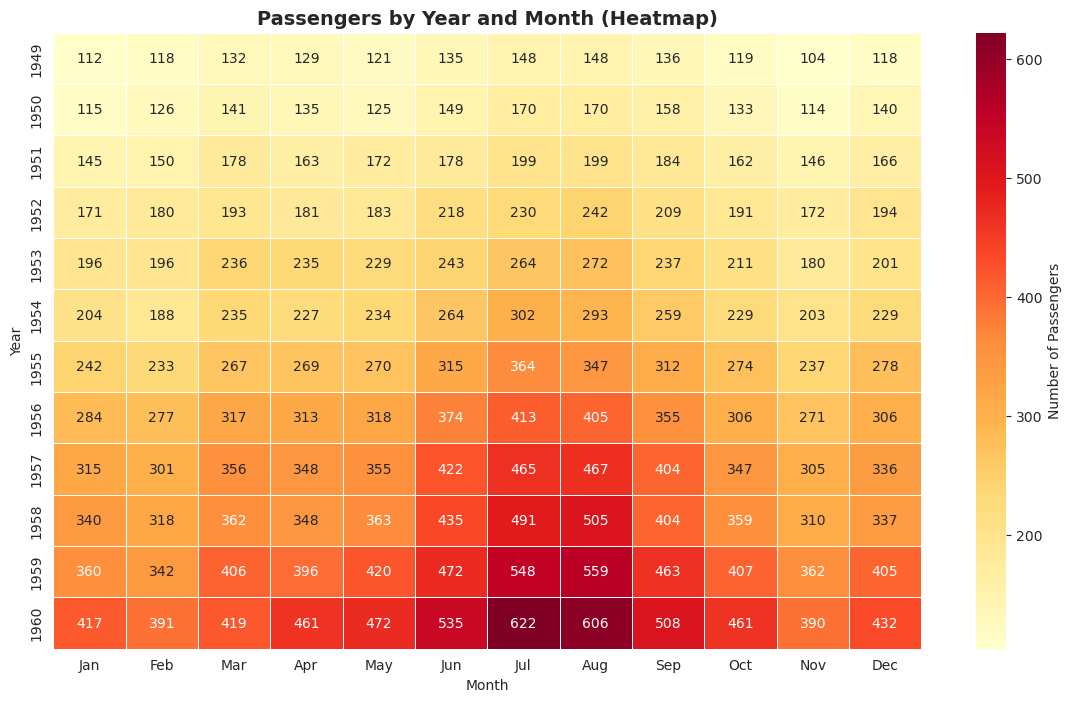

In [12]:
plt.figure(figsize=(14, 8))

heatmap_data = flights.pivot_table(index='year', columns='month',
                                    values='passengers', aggfunc='sum')
heatmap_data = heatmap_data[month_order]

sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='d',
            linewidths=0.5, cbar_kws={'label': 'Number of Passengers'})
plt.title('Passengers by Year and Month (Heatmap)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()

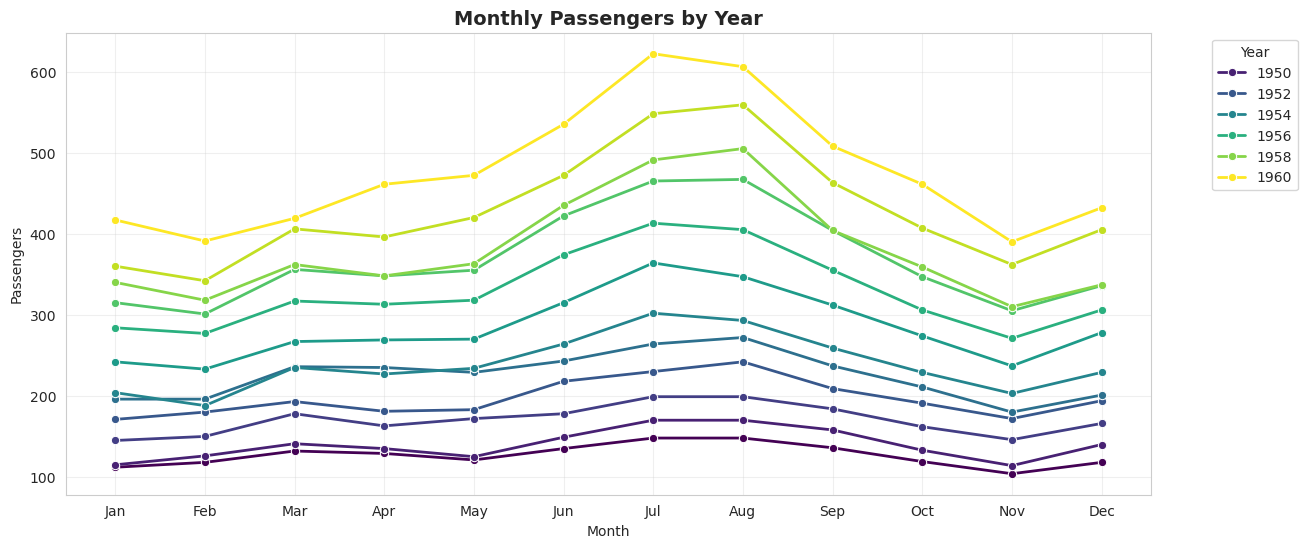

In [13]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=flights, x='month', y='passengers', hue='year',
             palette='viridis', linewidth=2, marker='o')
plt.title('Monthly Passengers by Year', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_607/657257780.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=flights, x='year', y='passengers', estimator=sum,


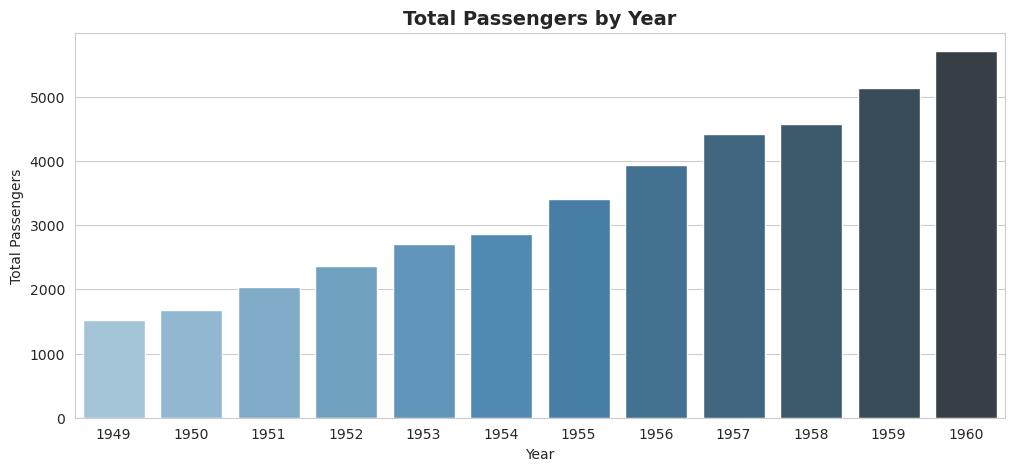

In [14]:
plt.figure(figsize=(12, 5))
sns.barplot(data=flights, x='year', y='passengers', estimator=sum,
            errorbar=None, palette='Blues_d')
plt.title('Total Passengers by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Passengers')
plt.show()